In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('cleaned_data.csv')


In [4]:
# Check the first few rows
df.head()

,APA Tenant,HasPay,Segment,Industry,Sub Industry,ERP,Medius Territory,Sum of Employees,Capture License Type,Sum of APA License utilization,...,AvgInvoicesPerMonth,AvgLinesPerInvoice,AvgOverdueDays,DistinctLanguages,AvgTimeToCompleteTask,TotalArchivedInvoices,OverdueInvoiceCount,MinInvoiceDate,RootCompanyCreatedTimestamp,Account Description
0,2xu,0,Mid-Market,Retail,Apparel & Accessories Retail,Apparel21,Medius Australia,240.0,RSO Bulk,38.0,...,456.153846,6.993494,27.394782,2,3.113441,5736,1150,3/22/2022 2:30,12/14/2021 5:24,"Founded in Australia in 2005, 2XU is a technic..."
1,4cgroup,0,Mid-Market,Professional Services,'-,Visma Administration,Medius Sweden,118.0,Medius Capture,45.0,...,123.454545,1.375829,16.686956,2,1.344115,1247,115,5/27/2024 9:08,4/15/2024 14:11,4C Strategies is a leading provider of organis...
2,4sound,0,Mid-Market,Retail,Sporting & Recreational Equipment Retail,Visma Global,Medius Sweden,35.0,'-,67.0,...,NaN,NaN,20.443534,3,NaN,0,0,9/19/2019 9:38,4/8/2019 9:20,Luthman SMTTS AB is a company that operates in...
3,aaacooper,0,Enterprise,Logistics / Transportation,Freight & Logistics Services,MS Dynamics AX,Medius North America,6200.0,Medius Capture,100.0,...,12031.307690,1.580532,18.215855,1,3.646129,150595,64886,9/23/2020 18:23,5/13/2020 22:10,"Founded in 1955, AAA Cooper Transportation, an..."
4,aaesbsp,0,Mid-Market,Retail,Office Products Retail & Distribution,Baan; Infor M3,Medius Sweden,151.0,Medius Capture,45.0,...,4511.000000,1.106293,21.382810,5,1.085951,53857,12915,1/9/2023 10:01,4/25/2022 11:52,Portsystem AB is a company that operates in th...


C:\Users\AmnaSaied\AppData\Local\Temp\ipykernel_5160\3534281136.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["HasPay"], palette=["#ff7f0e", "#1f77b4"])


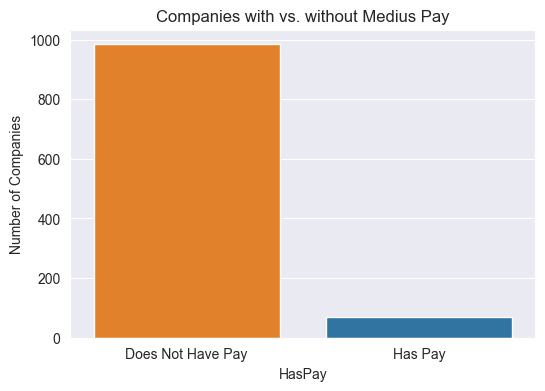

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=df["HasPay"], palette=["#ff7f0e", "#1f77b4"])
plt.xticks([0, 1], ["Does Not Have Pay", "Has Pay"])
plt.ylabel("Number of Companies")
plt.title("Companies with vs. without Medius Pay")
plt.show()



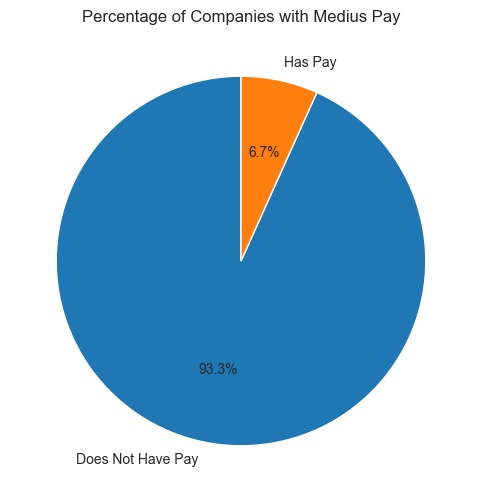

In [6]:
labels = ["Does Not Have Pay", "Has Pay"]
sizes = df["HasPay"].value_counts(normalize=True) * 100  # Convert to percentage
colors = ["#1f77b4", "#ff7f0e"]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%.1f%%", colors=colors, startangle=90)
plt.title("Percentage of Companies with Medius Pay")
plt.show()


In [7]:
numeric_cols = df.select_dtypes(include=["number"]).columns  # Select only numeric columns
df[numeric_cols].groupby(df["HasPay"]).mean()
#spoting important areas for exploration:
#activeSubsidiaries
#Sum of employees
#AvrgInvoices


,HasPay,Sum of Employees,Sum of APA License utilization,Sum of ACV (USD),Sum of Number of Locations,ActivatedModules,ActiveSubsidiaries,ActiveUsers,AvgCommentsPerDocument,AvgCompletedTasksPerWeek,AvgInvoicesPerMonth,AvgLinesPerInvoice,AvgOverdueDays,DistinctLanguages,AvgTimeToCompleteTask,TotalArchivedInvoices,OverdueInvoiceCount
HasPay,,,,,,,,,,,,,,,,,
0,0.0,3483.469512,65.569106,58716.312175,3.795732,7.886179,11.970528,363.302846,1.602227,6238.110796,3019.800450,2.511913,23.970883,2.354675,1.843220,33127.029472,5466.459350
1,1.0,1293.859155,64.000000,87999.063803,4.957746,10.943662,6.718310,255.943662,1.640935,5171.310224,2353.710877,2.086883,26.694966,1.507042,1.634084,25390.535211,6462.197183


Distribution of active subsidiaries by haspay

C:\Users\AmnaSaied\AppData\Local\Temp\ipykernel_5160\201525751.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(['HasPay', 'ActiveSubsidiaries_Binned']).size().reset_index(name='Count')


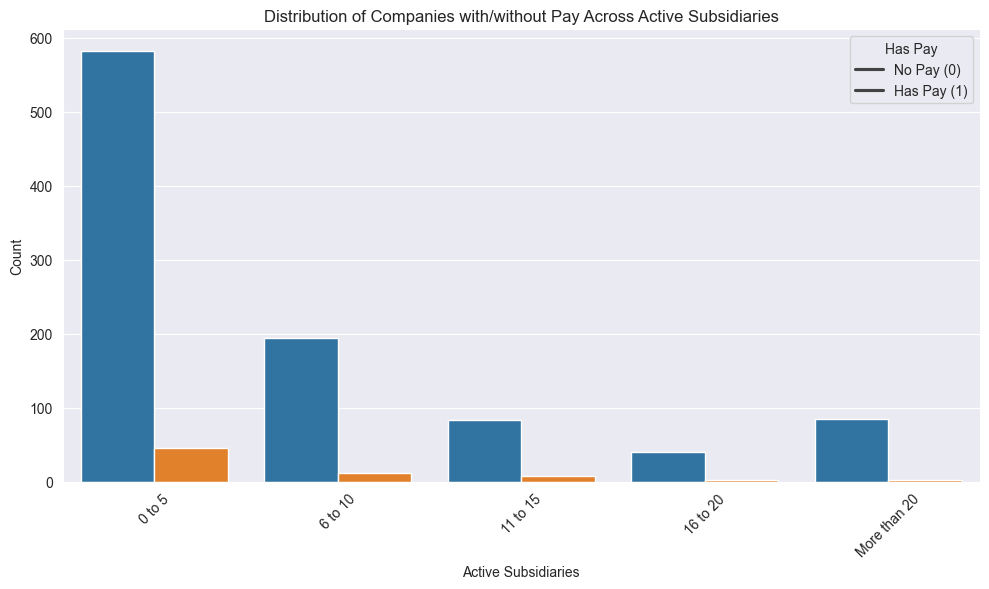

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the bins and labels for ActiveSubsidiaries
bins = [0, 5, 10, 15, 20, float('inf')]  # Defines the ranges
labels = ['0 to 5', '6 to 10', '11 to 15', '16 to 20', 'More than 20']

# Create a new column for binned ActiveSubsidiaries
df['ActiveSubsidiaries_Binned'] = pd.cut(df['ActiveSubsidiaries'], bins=bins, labels=labels, right=True)

# Group by 'HasPay' and the binned 'ActiveSubsidiaries'
df_grouped = df.groupby(['HasPay', 'ActiveSubsidiaries_Binned']).size().reset_index(name='Count')

# Plot the data
plt.figure(figsize=(10, 6))
sns.barplot(x='ActiveSubsidiaries_Binned', y='Count', hue='HasPay', data=df_grouped)

# Set chart title and labels
plt.title('Distribution of Companies with/without Pay Across Active Subsidiaries')
plt.xlabel('Active Subsidiaries')
plt.ylabel('Count')
plt.legend(title='Has Pay', labels=['No Pay (0)', 'Has Pay (1)'])

# Show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




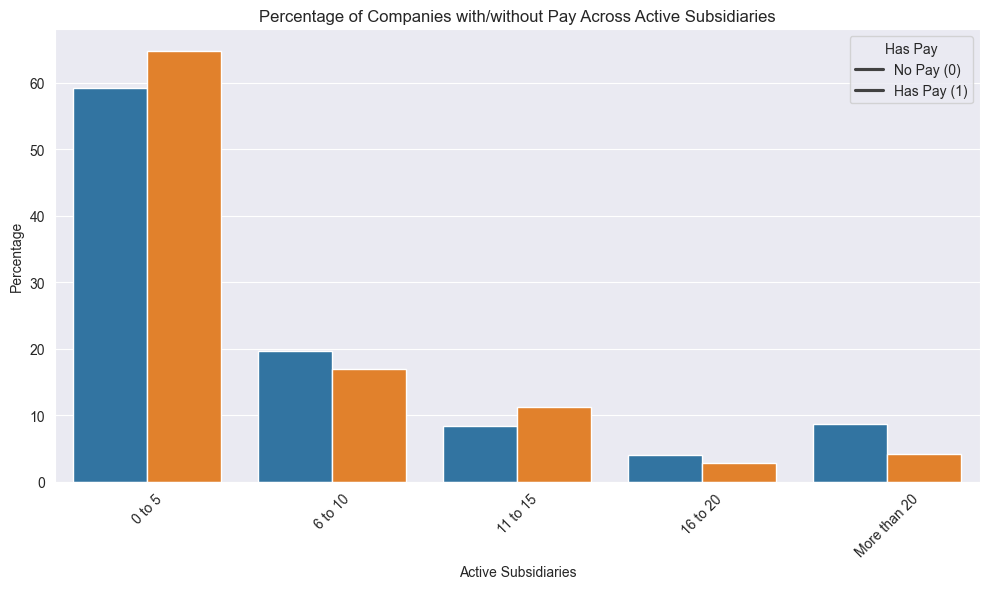

In [9]:
#% of pay companies out of total who have pay / same for not pay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the bins and labels for ActiveSubsidiaries
bins = [0, 5, 10, 15, 20, float('inf')]  # Defines the ranges
labels = ['0 to 5', '6 to 10', '11 to 15', '16 to 20', 'More than 20']


# Create a new column for binned ActiveSubsidiaries
df['ActiveSubsidiaries_Binned'] = pd.cut(df['ActiveSubsidiaries'], bins=bins, labels=labels, right=True)

# Group by 'HasPay' and the binned 'ActiveSubsidiaries'
df_grouped = df.groupby(['HasPay', 'ActiveSubsidiaries_Binned'], observed=False).size().reset_index(name='Count')


# Calculate the total number of companies in each HasPay group
total_has_pay = df_grouped[df_grouped['HasPay'] == 1]['Count'].sum()
total_no_pay = df_grouped[df_grouped['HasPay'] == 0]['Count'].sum()

# Calculate the percentage for each bin
df_grouped['Percentage'] = df_grouped.apply(lambda row: row['Count'] / total_has_pay * 100 if row['HasPay'] == 1 else row['Count'] / total_no_pay * 100, axis=1)

# Plot the data
plt.figure(figsize=(10, 6))
sns.barplot(x='ActiveSubsidiaries_Binned', y='Percentage', hue='HasPay', data=df_grouped)

# Set chart title and labels
plt.title('Percentage of Companies with/without Pay Across Active Subsidiaries')
plt.xlabel('Active Subsidiaries')
plt.ylabel('Percentage')
plt.legend(title='Has Pay', labels=['No Pay (0)', 'Has Pay (1)'])

# Show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Set chart title and labels


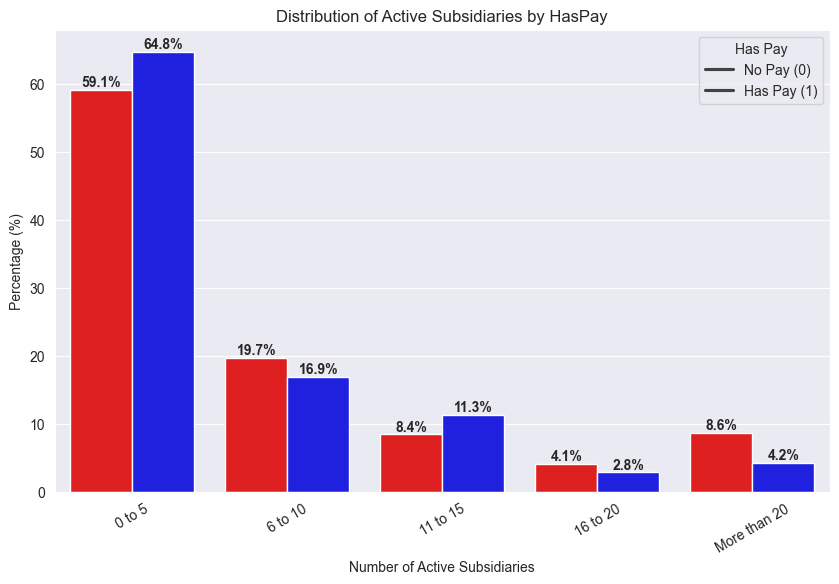

In [10]:
# Step 1: Define bins and labels
bins = [0, 5, 10, 15, 20, float('inf')]
labels = ['0 to 5', '6 to 10', '11 to 15', '16 to 20', 'More than 20']

# Step 2: Create the binned column
df['ActiveSubsidiaries_Binned'] = pd.cut(df['ActiveSubsidiaries'], bins=bins, labels=labels, right=True)

# Step 3: Count companies per bin, grouped by HasPay
df_grouped = df.groupby(['HasPay', 'ActiveSubsidiaries_Binned'], observed=False).size().reset_index(name='Count')

# Step 4: Fix index issue before calculating percentages
df_grouped['TotalPerGroup'] = df_grouped.groupby('HasPay')['Count'].transform('sum')

# Step 5: Calculate percentage within each HasPay category
df_grouped['Percentage'] = (df_grouped['Count'] / df_grouped['TotalPerGroup']) * 100

# Step 6: Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='ActiveSubsidiaries_Binned', y='Percentage', hue='HasPay', data=df_grouped,
            palette={0: 'red', 1: 'blue'})

# Step 7: Customize the plot
plt.xlabel("Number of Active Subsidiaries")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Active Subsidiaries by HasPay")
plt.legend(title="Has Pay", labels=["No Pay (0)", "Has Pay (1)"])
plt.xticks(rotation=30)

# Show values on top of bars
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:  # Only label bars that have a value
        plt.text(p.get_x() + p.get_width() / 2, height + 0.5, f"{height:.1f}%",
                 ha='center', fontsize=10, fontweight='bold')

plt.show()


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1055 entries, 0 to 1054
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   APA Tenant                      1055 non-null   object  
 1   HasPay                          1055 non-null   int64   
 2   Segment                         1055 non-null   object  
 3   Industry                        1055 non-null   object  
 4   Sub Industry                    1055 non-null   object  
 5   ERP                             1055 non-null   object  
 6   Medius Territory                1055 non-null   object  
 7   Sum of Employees                1055 non-null   float64 
 8   Capture License Type            1055 non-null   object  
 9   Sum of APA License utilization  1055 non-null   float64 
 10  AP Automation                   1055 non-null   bool    
 11  Sum of ACV (USD)                1055 non-null   float64 
 12  Sum of Number of Loc

In [16]:
# Ensure 'HasPay' is properly formatted (convert to integer if necessary)
df["HasPay"] = df["HasPay"].astype(int)

# 🔹 Check distribution of 'segment' for companies that have Pay
pay_segment_distribution = df[df["HasPay"] == 1]["segment"].value_counts()
no_pay_segment_distribution = df[df["HasPay"] == 0]["segment"].value_counts()

# 🔹 Print the distributions
print("Segment distribution for companies with Pay:\n", pay_segment_distribution)
print("\nSegment distribution for companies without Pay:\n", no_pay_segment_distribution)

# 🔹 Create a grouped table
segment_distribution = df.groupby(["HasPay", "segment"]).size().unstack()
print("\nGrouped segment distribution:\n", segment_distribution)

# 🔹 Visualize with a Bar Chart
plt.figure(figsize=(12, 6))

pay_segment_distribution.plot(kind="bar", alpha=0.6, color="blue", label="Has Pay")
no_pay_segment_distribution.plot(kind="bar", alpha=0.6, color="red", label="No Pay")

plt.xlabel("Segment")
plt.ylabel("Count")
plt.title("Segment Distribution: Companies with Pay vs. Without Pay")
plt.legend()
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

KeyError: 'segment'